In [ ]:
#abrir imagen RGB de tejido H&E
#aplicar alguna tecnica de mejora de contraste
#aplicar gmm fuzzy para 4 distrubciones
#contabilizar cuantos pixeles hay por cada uno de los clusters 
#mostrar en pantalla las 4 distribuciones, la imagen original y cuantos pixeles por cluster hay


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.preprocessing import MinMaxScaler
import os
import pandas as pd
from scipy.stats import f_oneway
import scipy.stats as stats
import seaborn as sns


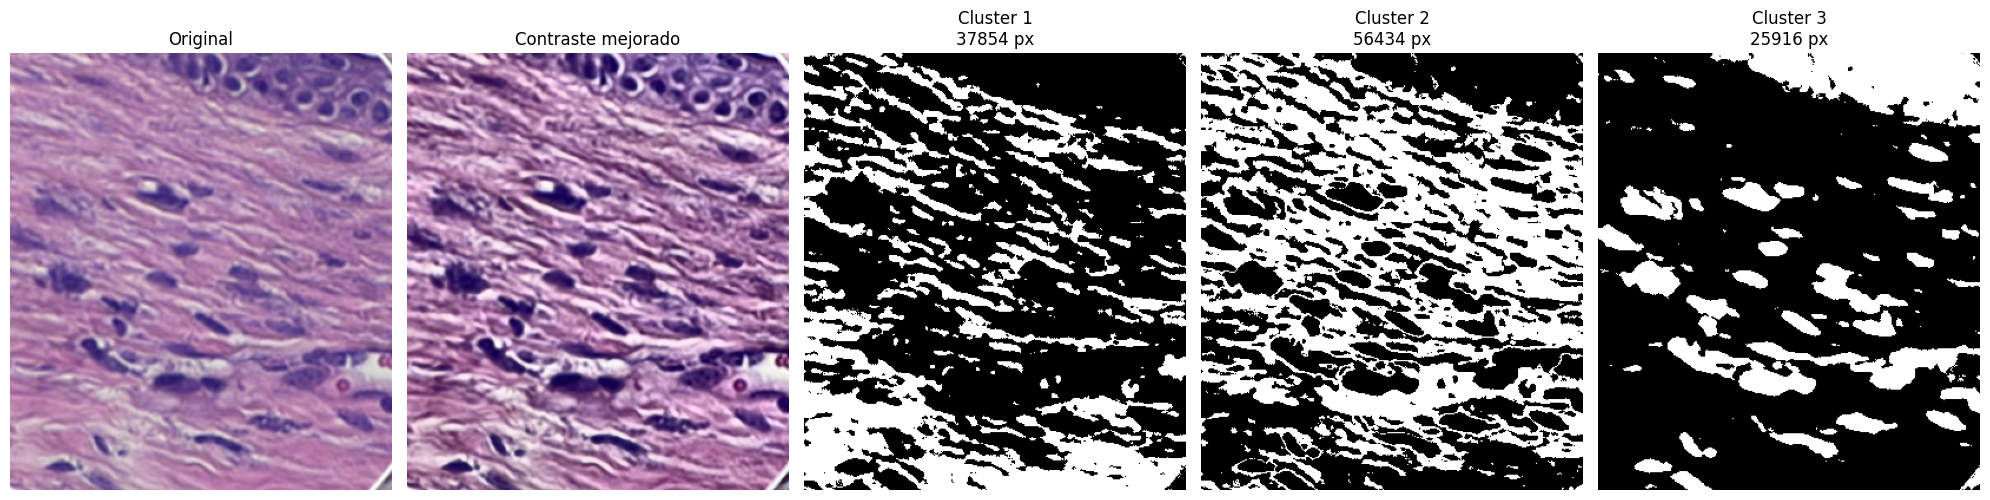

In [30]:

# 1. Cargar imagen RGB
ruta_imagen = 'ims\CP.png'
imagen_rgb = cv2.imread(ruta_imagen)
imagen_rgb = cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2RGB)

# 2. Mejora de contraste (CLAHE aplicado al canal de luminancia)
def mejora_contraste_rgb(img_rgb):
    img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_ycrcb)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    y_eq = clahe.apply(y)
    img_ycrcb_eq = cv2.merge((y_eq, cr, cb))
    img_eq = cv2.cvtColor(img_ycrcb_eq, cv2.COLOR_YCrCb2RGB)
    return img_eq

imagen_mejorada = mejora_contraste_rgb(imagen_rgb)

# 3. Redimensionar imagen y preparar datos para clustering
pixels = imagen_mejorada.reshape(-1, 3).astype(np.float64)
escaler = MinMaxScaler()
pixels_norm = escaler.fit_transform(pixels.T)  # Normaliza cada canal [0, 1]

# 4. Aplicar GMM-Fuzzy con 4 clústeres
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data=pixels_norm, c=3, m=2.0, error=0.005, maxiter=1000, init=None
)

# 5. Obtener etiquetas de mayor pertenencia
labels = np.argmax(u, axis=0)
labels_img = labels.reshape(imagen_mejorada.shape[:2])

# 6. Contar pixeles por clúster
conteos = np.bincount(labels, minlength=3)

# 7. Visualizar resultados
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(imagen_mejorada)
axes[1].set_title("Contraste mejorado")
axes[1].axis('off')

# Mostrar cada cluster como máscara
for i in range(3):
    mascara = (labels_img == i).astype(np.uint8) * 255
    axes[i+2].imshow(mascara, cmap='gray')
    axes[i+2].set_title(f'Cluster {i+1}\n{conteos[i]} px')
    axes[i+2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#reconstruir las imagenes con los pixeles de la imagen con contraste mejorado en cada uno de los clusters resultantes 
#y mostrarlas en pantalla 

Imágenes guardadas en: c:\Users\psiqu\OneDrive\Documentos\proyecto dra osvelia\clusters_guardados


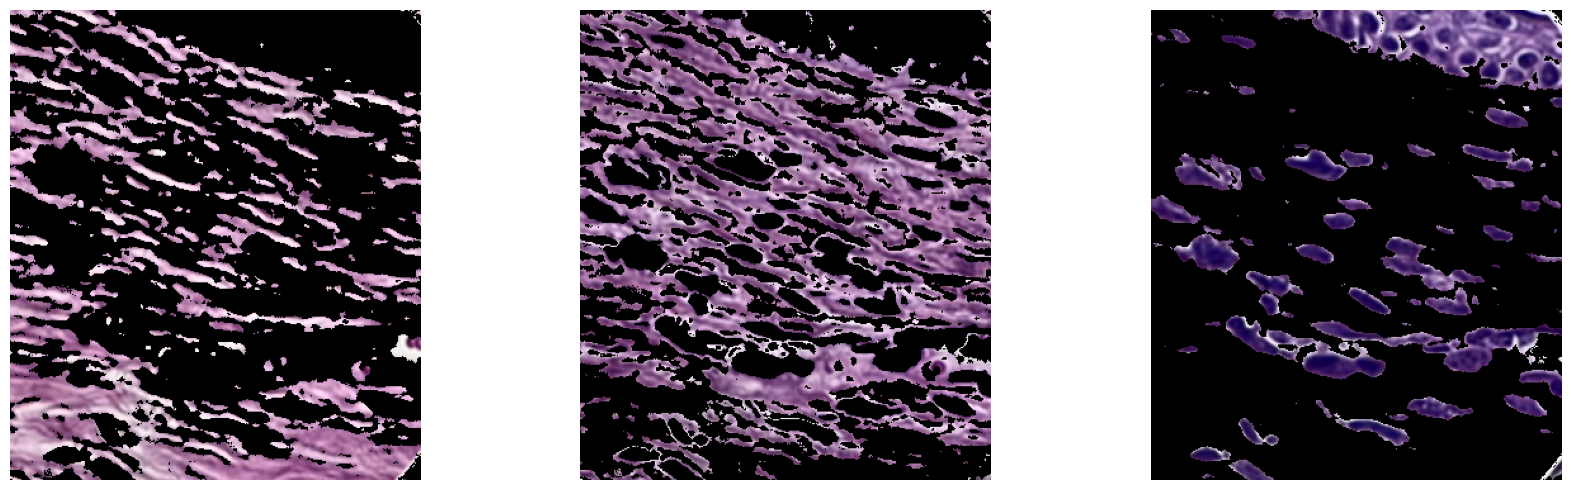

In [31]:
# 8. Reconstruir imágenes por clúster (con los colores originales del contraste mejorado)
imagenes_cluster = []

for i in range(3):  # ← nota que tienes 3 clusters aquí
    # Crear máscara booleana para el clúster actual
    mascara = (labels_img == i)
    
    # Crear imagen vacía negra
    img_cluster = np.zeros_like(imagen_mejorada)
    
    # Asignar los valores de los píxeles del clúster a su lugar correspondiente
    img_cluster[mascara] = imagen_mejorada[mascara]
    
    imagenes_cluster.append(img_cluster)

# Guardar imágenes con nombre basado en la imagen original
nombre_base = os.path.splitext(os.path.basename(ruta_imagen))[0]
carpeta_salida = "clusters_guardados"
os.makedirs(carpeta_salida, exist_ok=True)

for i, img_cluster in enumerate(imagenes_cluster):
    nombre_archivo = f"{nombre_base}_cluster{i+1}.png"
    ruta_salida = os.path.join(carpeta_salida, nombre_archivo)
    
    # Convertir de RGB a BGR antes de guardar
    img_bgr = cv2.cvtColor(img_cluster, cv2.COLOR_RGB2BGR)
    cv2.imwrite(ruta_salida, img_bgr)

print(f"Imágenes guardadas en: {os.path.abspath(carpeta_salida)}")

# 9. Mostrar imágenes reconstruidas por clúster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.imshow(imagenes_cluster[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [32]:
# 10. Guardar el conteo de píxeles por clúster en un archivo CSV
df_conteo = pd.DataFrame({
    'Cluster': [f'Cluster {i+1}' for i in range(3)],
    'Pixeles': conteos
})

# Ruta del archivo CSV (ajústala si quieres cambiar la ubicación o nombre)
df_conteo.to_csv('3clusters/CP/conteo_pixeles_3clusters_CP.csv', index=False)

print("Conteo de píxeles guardado")


Conteo de píxeles guardado


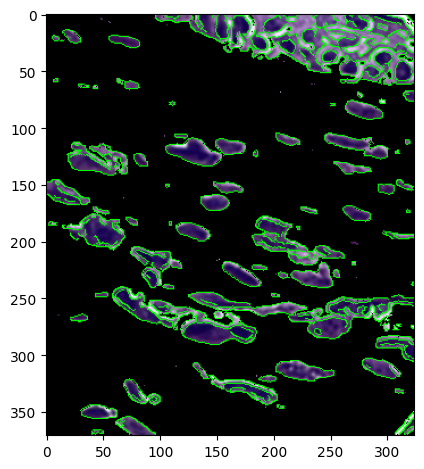

In [58]:
# 1. Cargar imagen segmentada
ruta_imagen_segmento_morado = '3clusters/CP/clusters_guardados/CP_cluster3.png'
imagen_rgb_segmento_morado = cv2.imread(ruta_imagen_segmento_morado)
imagen_rgb_segmento_morado = cv2.cvtColor(imagen_rgb_segmento_morado, cv2.COLOR_BGR2RGB)

# 2. Convertir a escala de grises y aplicar desenfoque (opcional pero recomendable para Canny)
imagen_gris = cv2.cvtColor(imagen_rgb_segmento_morado, cv2.COLOR_RGB2GRAY)
imagen_gris = cv2.GaussianBlur(imagen_gris, (5, 5), 0)

# 3. Detectar bordes con Canny
bordes = cv2.Canny(imagen_gris, 50, 150)

# 4. Encontrar contornos
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5. Dibujar todos los contornos
imagen_todos = imagen_rgb_segmento_morado.copy()
cv2.drawContours(imagen_todos, contornos, -1, (0, 255, 0), 1)

plt.imshow(imagen_todos)
plt.tight_layout()
plt.show()


In [59]:
#metricas morfológicas

# 1. Cargar imagen segmentada
ruta_imagen_segmento_morado = '3clusters/CP/clusters_guardados/CP_cluster3.png'
imagen_rgb_segmento_morado = cv2.imread(ruta_imagen_segmento_morado)
imagen_rgb_segmento_morado = cv2.cvtColor(imagen_rgb_segmento_morado, cv2.COLOR_BGR2RGB)

# 2. Convertir a escala de grises y aplicar desenfoque
imagen_gris = cv2.cvtColor(imagen_rgb_segmento_morado, cv2.COLOR_RGB2GRAY)
imagen_gris = cv2.GaussianBlur(imagen_gris, (5, 5), 0)

# 3. Detectar bordes con Canny
bordes = cv2.Canny(imagen_gris, 50, 150)

# 4. Encontrar contornos
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5. Calcular métricas morfológicas
metricas = []

for i, contorno in enumerate(contornos):
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)

    if perimetro == 0 or area == 0:
        continue

    # Bounding box
    x, y, w, h = cv2.boundingRect(contorno)
    aspect_ratio = w / h if h != 0 else 0
    extent = area / (w * h) if (w * h) != 0 else 0
    rectangularidad = area / (w * h) if (w * h) != 0 else 0

    # Solidez
    hull = cv2.convexHull(contorno)
    area_hull = cv2.contourArea(hull)
    solidez = area / area_hull if area_hull != 0 else 0

    # Circularidad y compacidad
    circularidad = (4 * np.pi * area) / (perimetro ** 2)
    compacidad = (perimetro ** 2) / area

    # Diámetro equivalente circular
    diametro_eq = np.sqrt((4 * area) / np.pi)

    # Ejes de elipse si el contorno tiene suficientes puntos
    try:
        if len(contorno) >= 5:
            (x_elp, y_elp), (MA, ma), angle = cv2.fitEllipse(contorno)
            excentricidad = np.sqrt(1 - (MA / ma) ** 2) if ma != 0 else 0
            elongacion = ma / MA if MA != 0 else 0
        else:
            excentricidad = 0
            elongacion = 0
    except:
        excentricidad = 0
        elongacion = 0

    # Almacenar
    metricas.append({
        'ID_Contorno': i+1,
        'Area': area,
        'Perimetro': perimetro,
        'Solidez': solidez,
        'Circularidad': circularidad,
        'Aspect_Ratio': aspect_ratio,
        'Extent': extent,
        'Rectangularidad': rectangularidad,
        'Compacidad': compacidad,
        'Diametro_EQ': diametro_eq,
        'Excentricidad': excentricidad,
        'Elongacion': elongacion
    })


# 6. Convertir a DataFrame
df = pd.DataFrame(metricas)

# 7. Calcular promedio de cada métrica
promedios = df[['Area', 'Perimetro', 'Solidez', 'Circularidad', 'Aspect_Ratio']].mean()
promedios_df = pd.DataFrame(promedios).T
promedios_df.insert(0, 'ID_Contorno', 'Promedio')

# 8. Unir DataFrames
df_final = pd.concat([df, promedios_df], ignore_index=True)

# 9. Guardar en CSV
df_final.to_csv('metricas_morfologicas.csv', index=False)
print("CSV guardado como 'metricas_morfologicas.csv'")


CSV guardado como 'metricas_morfologicas.csv'


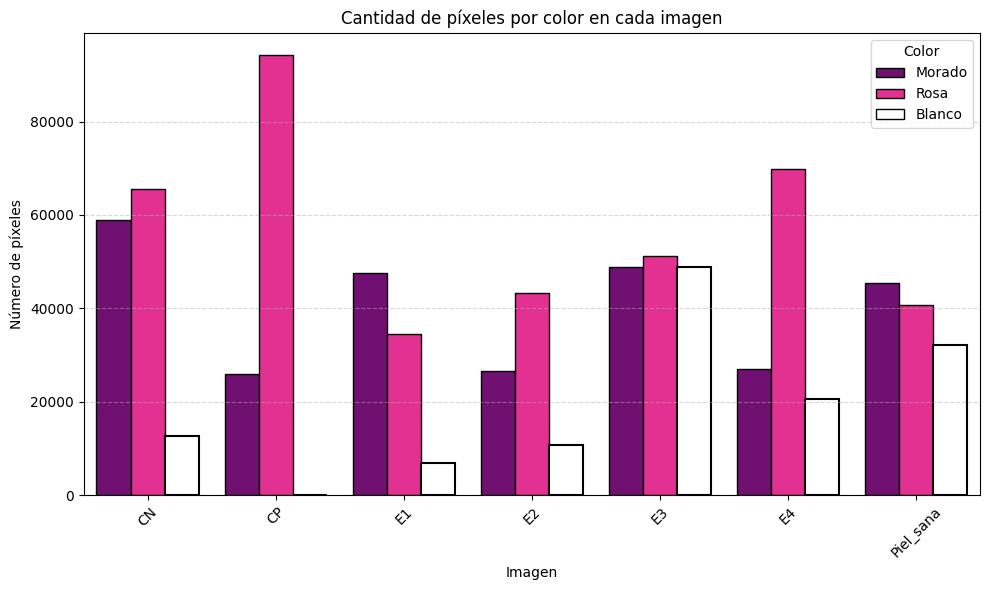

In [ ]:
# Cargar el archivo
ruta = '3clusters/Conteo de pixeles_totales.xlsx'
df = pd.read_excel(ruta)

# Asegurar que la primera columna sea el índice
df.set_index(df.columns[0], inplace=True)

# Columnas de colores que se van a graficar
colores = ['Morado', 'Rosa', 'Blanco']

# Convertir el DataFrame a formato "long" para Seaborn
df_melted = df[colores].reset_index().melt(id_vars=df.index.name, var_name='Color', value_name='Pixeles')

# Configurar colores personalizados
color_map = {
    'Morado': 'purple',
    'Rosa': 'deeppink',
    'Blanco': 'white'  # barra blanca con borde negro
}

# Crear el gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x=df.index.name, y='Pixeles', hue='Color', palette=color_map, edgecolor='black')

# Asegurar que la barra blanca tenga contorno negro
for patch, color in zip(ax.patches, df_melted['Color']):
    if color == 'Blanco':
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)

# Estética
plt.title('Cantidad de píxeles por color en cada imagen')
plt.ylabel('Número de píxeles')
plt.xlabel('Imagen')
plt.xticks(rotation=45)
plt.legend(title='Color')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

########morado heterocomatina y nucleolos
# ARN ribosomal
# matriz extracelular
# ####### Rosa  
#Filamentos citoplásmaticos 
#componentes membranosos intracelulares
# Fibras extracelulares

In [18]:
import pandas as pd
from scipy.stats import f_oneway

# Cargar archivos
ruta_cn = '3clusters/CP/metricas_morfologicas.csv'
ruta_e1 = '3clusters/E4/metricas_morfologicas.csv'

df_cn = pd.read_csv(ruta_cn)
df_e1 = pd.read_csv(ruta_e1)

# Excluir primera columna (ID) y última fila (resumen)
df_cn = df_cn.iloc[:-1, 1:]
df_e1 = df_e1.iloc[:-1, 1:]

# Asegurar columnas comunes
columnas_comunes = df_cn.columns.intersection(df_e1.columns)

# Lista para almacenar resultados
resultados = []

for columna in columnas_comunes:
    try:
        grupo1 = df_cn[columna].dropna().astype(float)
        grupo2 = df_e1[columna].dropna().astype(float)

        f_stat, p_val = f_oneway(grupo1, grupo2)

        interpretacion = 'Significativa (p < 0.05)' if p_val < 0.05 else 'No significativa'

        resultados.append({
            'Métrica': columna,
            'F': round(f_stat, 4),
            'p': f"{p_val:.4e}",
            'Interpretación': interpretacion
        })

    except Exception as e:
        resultados.append({
            'Métrica': columna,
            'F': 'Error',
            'p': 'Error',
            'Interpretación': f"Error: {str(e)}"
        })

# Convertir a DataFrame y guardar como CSV
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv('resultados_anova_morfologia_CP_E4.csv', index=False)

print("\n✔️ Resultados guardados en 'resultados_anova_morfologia.csv'")



✔️ Resultados guardados en 'resultados_anova_morfologia.csv'
